# **Step2_AI 강사 Agent v2.0**

## **0. 미션**

### **미션③ : 모듈 고도화1**
다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.

* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토




### **미션④ : AI 강사 Agent 완성**
* 모듈 고도화2(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
    * 음성 변환 : 강의 목소리, 톤 조절 음성 변환
    * 영상 제작 :
        * 각 페이지 : 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
        * 전체 강의 영상 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 웹 화면 연결(gradio)
    * 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 전체 Agent 그래프 구축
    * 전체를 Agent 그래프로 엮기


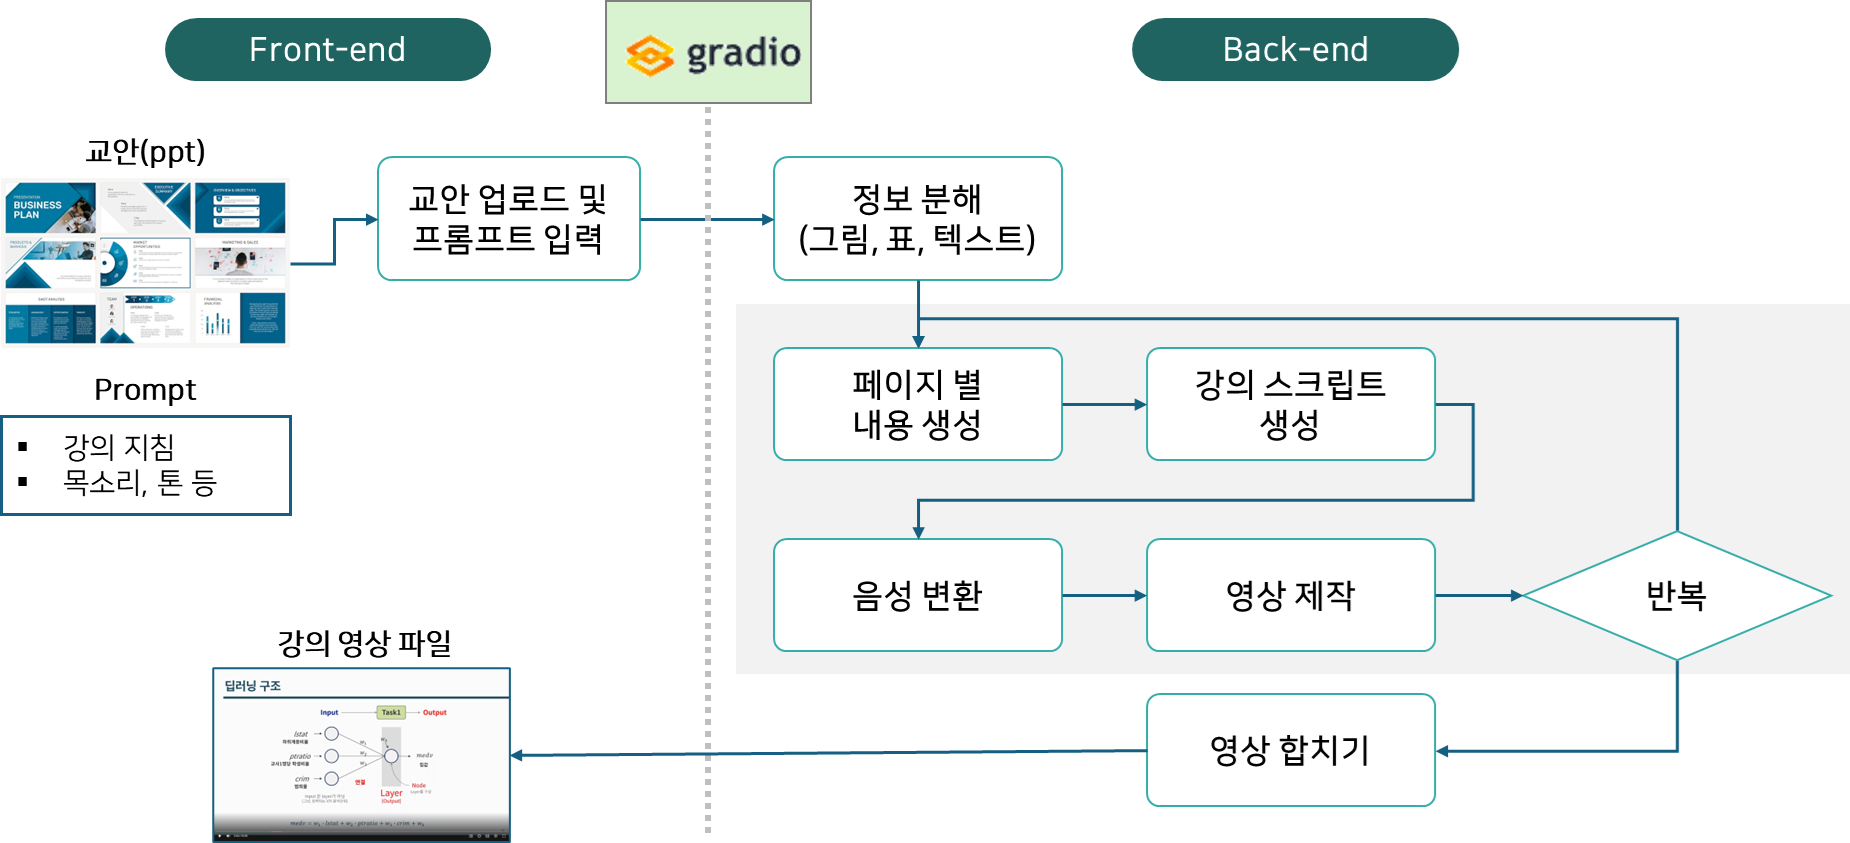

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj1_agent`를 생성하고
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 한글 폰트 준비
* 한글 폰트 설치 및 설정 코드
* 영상 제작 등 한글 사용시 필요

In [ ]:
%%bash
set -e

# (1) 필수 패키지
sudo apt-get update -y
sudo apt-get install -y \
  libreoffice poppler-utils poppler-data ffmpeg locales fontconfig xvfb \
  fonts-noto-core fonts-noto-cjk fonts-noto-cjk-extra

# (2) 로케일
sudo sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
sudo locale-gen ko_KR.UTF-8
sudo update-locale LANG=ko_KR.UTF-8

# (3) 기존에 만들었던 사용자 fonts.conf(전체 덮어쓰기) 제거
rm -f ~/.config/fontconfig/fonts.conf || true

# (4) 시스템 fontconfig에 로컬 룰로만 추가 (기본 설정은 그대로 사용)
sudo tee /etc/fonts/local.conf >/dev/null <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

  <!-- 한국어는 Noto Sans KR 우선 -->
  <match target="pattern">
    <test name="lang" compare="contains"><string>ko</string></test>
    <edit name="family" mode="prepend" binding="strong">
      <string>Noto Sans KR</string>
      <string>Noto Sans CJK KR</string>
      <string>Noto Sans</string>
    </edit>
  </match>

  <!-- 흔한 한글 폰트명을 Noto Sans KR로 매핑 -->
  <alias><family>Malgun Gothic</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>맑은 고딕</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>Apple SD Gothic Neo</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>AppleGothic</family><prefer><family>Noto Sans KR</family></prefer></alias>

</fontconfig>
EOF

# (5) 캐시 완전 재생성
rm -rf ~/.cache/fontconfig
sudo fc-cache -r
fc-cache -f -v >/dev/null

# (6) 검증
echo "---- fc-match ko ----"
fc-match "sans-serif:lang=ko"
echo "---- noto candidates ----"
fc-list | grep -i -E "noto.*(sans|cjk).*kr" | head -n 30 || true

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,546 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main 

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 150.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


### (3) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install langchain-openai langchain-community python-pptx pillow gradio langchain-tavily tavily-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


* 라이브러리 로딩

In [ ]:
import os, re, textwrap, subprocess, json, base64, mimetypes, shlex
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Optional, TypedDict, Any
from PIL import Image, ImageDraw
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE
from openai import OpenAI
from google.colab import files
from IPython.display import Audio, display, Video

from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

### (4) API Key 확인
* 구글드라이브에 생성한 폴더 `proj1_agent` 에서
* api_key.txt 파일 안에 각자 발급 받은 키를 저장합니다.
    * **OPENAI_API_KEY**
    * **TAVILY_API_KEY**

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/kt aivle 9기/proj1_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

### (5) 유용한 함수들 제공
* 다음은 프로젝트를 수행하는데 유용한 함수들입니다.
* 이 함수들의 내용을 확인하고 필요시 활용하여 개인 과제를 수행합니다.(꼭 활용해야 하는 것은 아닙니다.)

* 공백 제거 함수

In [ ]:
def clean_text(s):
    return re.sub(r"\s+", " ", s).strip()

* 긴 문자열을 문장 단위로 나누는 문장 분리기

In [ ]:
def split_sents(t: str) -> List[str]:
    parts = re.split(r'([\.?!])', t)
    merged = []
    for i in range(0, len(parts)-1, 2):
        sent = (parts[i] + parts[i+1]).strip()
        if sent: merged.append(sent)
    if len(parts) % 2 == 1 and parts[-1].strip():
        merged.append(parts[-1].strip())
    return [s for s in merged if s]

* 오디오 길이 계산

In [ ]:
def ffprobe_duration(path: str) -> float:
    out = subprocess.check_output([
        "ffprobe","-v","error","-show_entries","format=duration",
        "-of","default=noprint_wrappers=1:nokey=1", path]).decode().strip()
    return float(out)

* 이미지를 base64로 변환

In [ ]:
def img_to_data_url(path: str) -> str:
    mime = mimetypes.guess_type(path)[0] or "image/png"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

* 배경 이미지와 오디오 합쳐서 MP4 영상 만들기

In [ ]:
def render_mp4(image_path: str, audio_path: str, out_mp4: str,
               width=1920, height=1080, ):

    dur = ffprobe_duration(audio_path)

    vf = (f"scale={width}:{height}:force_original_aspect_ratio=decrease,"
          f"pad={width}:{height}:(ow-iw)/2:(oh-ih)/2:color=black"  )

    # FFmpeg 명령
    cmd = ["ffmpeg", "-y",
            "-loop", "1", "-i", image_path,   # 정지 이미지 입력
            "-i", audio_path,                 # 오디오 입력
            "-t", str(dur),                   # 길이 = 오디오 길이
            "-vf", vf,                        # 비디오 필터
            "-c:v", "libx264", "-preset", "veryfast", "-crf", "20",
            "-c:a", "aac", "-b:a", "192k",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",        # 웹/브라우저 재생 친화
            out_mp4]
    subprocess.check_call(cmd)  # 외부 프로그램(FFmpeg)을 파이썬 프로세스에서 실행하고, 성공했는지 확인

* ppt 슬라이드를 배경 이미지로 저장
    * 강의 영상에서 사용할 배경 이미지 생성하기
    * ppt를 pdf로 변환한 뒤 다시 이미지로 변환

In [ ]:
import os, subprocess, uuid
from pathlib import Path

def export_slide_as_png(state: dict, dpi: int = 220) -> dict:
    work_dir = Path(state["work_dir"]).expanduser().resolve()
    work_dir.mkdir(parents=True, exist_ok=True)

    pptx = Path(state["pptx_path"]).expanduser().resolve()
    if not pptx.exists():
        raise FileNotFoundError(f"PPTX 없음: {pptx}")

    idx = int(state.get("slide_index", 0))  # 0-based
    page_no = idx + 1
    out_prefix = work_dir / "slide_img"

    # LibreOffice 프로필(캐시) 꼬임 방지
    lo_profile = f"file:///tmp/lo_profile_{uuid.uuid4().hex}"

    # fontconfig/locale 강제
    env = os.environ.copy()
    env.update({
        "LANG": "ko_KR.UTF-8",
        "LC_ALL": "ko_KR.UTF-8",
        "FONTCONFIG_PATH": str(Path("~/.config/fontconfig").expanduser()),
        "FONTCONFIG_FILE": str(Path("~/.config/fontconfig/fonts.conf").expanduser()),
        "HOME": str(Path("~").expanduser()),
        "XDG_CACHE_HOME": str(Path("~/.cache").expanduser()),
        "SAL_USE_VCLPLUGIN": "gen",
    })

    def run_lo_convert(convert_to: str):
        # X11 요구 해결: xvfb-run로 감싼다 (Colab 필수급)
        cmd = [
            "xvfb-run", "-a",
            "soffice", "--headless", "--nologo", "--nofirststartwizard", "--norestore",
            f"-env:UserInstallation={lo_profile}",
            "--convert-to", convert_to,
            "--outdir", str(work_dir),
            str(pptx),
        ]
        return subprocess.run(cmd, capture_output=True, text=True, env=env)

    # --- A) PPTX → PNG ---
    before_png = set(work_dir.glob("*.png"))
    res_png = run_lo_convert("png:impress_png_Export")

    created_png = [p for p in work_dir.glob("*.png") if p not in before_png]
    candidate = None

    exact = [p for p in created_png if p.stem.endswith(f"-{page_no}")]
    if exact:
        candidate = max(exact, key=lambda p: p.stat().st_mtime)
    elif created_png:
        candidate = max(created_png, key=lambda p: p.stat().st_mtime)

    if candidate and candidate.exists():
        state["slide_image"] = str(candidate)
        return state

    # --- B) 폴백: PPTX → PDF → PNG ---
    before_pdf = set(work_dir.glob("*.pdf"))
    res_pdf = run_lo_convert("pdf:impress_pdf_Export")

    target_pdf = work_dir / f"{pptx.stem}.pdf"
    created_pdf = [p for p in work_dir.glob("*.pdf") if p not in before_pdf]

    if target_pdf.exists():
        pdf_path = target_pdf
    elif created_pdf:
        pdf_path = max(created_pdf, key=lambda p: p.stat().st_mtime)
    else:
        print("LibreOffice PPTX→PDF 변환 실패")
        print("stdout:", res_pdf.stdout)
        print("stderr:", res_pdf.stderr)
        raise RuntimeError("PPTX → PDF 변환 실패")

    ppm_cmd = [
        "pdftoppm",
        "-f", str(page_no), "-l", str(page_no),
        "-png", "-r", str(dpi),
        str(pdf_path),
        str(out_prefix)
    ]
    res2 = subprocess.run(ppm_cmd, capture_output=True, text=True, env=env)

    png_path = Path(f"{out_prefix}-{page_no}.png")
    if not png_path.exists():
        print("pdftoppm 변환 실패")
        print("stdout:", res2.stdout)
        print("stderr:", res2.stderr)
        raise RuntimeError("PDF → PNG 변환 실패")

    state["slide_image"] = str(png_path)
    return state

* 영상 합치기 : 여러 영상 경로를 리스트로 입력 받아 합치기

In [ ]:
def concat_videos_ffmpeg(video_paths: List[str], out_path: str, reencode: bool=False):
    list_path = out_path + ".txt"
    with open(list_path, "w", encoding="utf-8") as f:
        for v in video_paths:
            f.write(f"file '{os.path.abspath(v)}'\n")
    if reencode:
        cmd = [
            "ffmpeg","-y","-safe","0","-f","concat","-i",list_path,
            "-vf","format=yuv420p",
            "-c:v","libx264","-preset","veryfast",
            "-c:a","aac","-b:a","192k",
            out_path
        ]
    else:
        cmd = ["ffmpeg","-y","-safe","0","-f","concat","-i",list_path,"-c","copy",out_path]
    subprocess.check_call(cmd)

-----

**[주의!]**🚨🚨🚨🚨🚨
* 아래 제공되는 코드 혹은 노드를 그대로 사용할 경우, 오류가 발생될 수 있습니다.
* 코드 내용을 반드시 확인하고, 여러분의 프로젝트에 맞게 수정해서 사용하세요.

-----

## **2. 미션③ : 모듈 고도화1**
(다음 항목에 대해서 조 상황에 맞게 선택적으로 고도화 합니다.)
* 입력 프롬프트 추가 : 강의 목소리, 톤 조절, 강의 스타일 지침
* 정보 분해 : 여러 슬라이드를 저장하고 관리하기 위한 폴더 준비, 불필요한 정보 제거, 제목 추출
* 페이지별 내용 생성 : 슬라이드 내 정보 뿐만 아니라 부연 설명을 위한 검색 기능 추가
* 강의 스크립트 생성 : 전체 강의 내용을 참조하여 강의 흐름을 구상하고,
                                   현재 페이지 강의 스크립트 작성
* 내용 검토 : 페이지 내용과 강의 스크립트 비교, 강의 스크립트 흐름 적절한지 검토

### (1) 파일 입력

* ppt 파일



In [ ]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving test ppt 2.pptx to test ppt 2.pptx


In [ ]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "alloy",
    "tone": "전문적인 지식을 가진 인기 강사 톤",
    "style": "예시와 핵심 요점 중심",
    "summary_purpose":"논문 발표 복습용 요약" #추가
}
# 출력 dir 만들기
WORK_DIR = "./step2_output"
MEDIA_DIR = "./step2_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) State 선언

* 각 노드의 입출력 관리를 위한 State 구성
    * 각 함수(노드)에서 채워가며 관리해야 할 정보를 도출
    * 이를 하나의 State로 정의


In [ ]:
class State(TypedDict, total=False):
    # 입력/설정
    pptx_path: str
    work_dir: str
    prompt: Dict[str, Any]  # {"voice":..., "tone":..., "style":...}

    # 파싱 결과(다중 슬라이드)
    slides: List[Dict[str, Any]]  # [{index,title,texts,tables,images,snap}]
    n_slides: int
    slide_index: int  # 현재 슬라이드 index

    # 생성/미디어 누적 산출물
    page_contents: List[str]       # page 내용 정리
    scripts: List[str]             # page 강의 스크립트
    audios: List[str]
    videos: List[str]
    final_video: str

    # 임시(반복 내부 사용)
    cur_search_context: str
    cur_page_content: str
    cur_script: str
    cur_audio: str
    cur_video: str

    summary: List[str]
    cur_summary: str

    # 내용 검토 관련
    review_feedback: str
    review_result: str  # PASS 또는 RETRY

    # FAQ
    total_faq: str

    # 요약본 작성
    summary_text: str
    summary_path: str
    summary_purpose: str
    summary_pdf: str

In [ ]:
state: State = {"pptx_path": pptx_path, "work_dir": WORK_DIR, "prompt": USER_PROMPT}

In [ ]:
LLM_MODEL = "gpt-4o-mini"
TTS_MODEL = "gpt-4o-mini-tts"

In [ ]:
llm = ChatOpenAI(model=LLM_MODEL, temperature=0.3)

### (3) ppt 정보 분해
* 목적: 전체 슬라이드의 텍스트/표/이미지/스냅샷 수집 → state["slides"] 적재
* 입력: pptx_path, work_dir
* 출력: 슬라이드마다, text, image, text, 스냅(스크린샷) 등 저장
* 처리:
    * python-pptx로 텍스트/표/이미지 추출
    * 제목 추출
    * export_slide_as_png로 snap 생성

* 노드 함수 생성 (일부 제공)

In [ ]:
def node_parse_all(state: State) -> State:
    '파서 노드 내부에서 반복문으로 모든 슬라이드 텍스트/표/이미지 + 스냅샷 생성'
    pres = Presentation(state["pptx_path"])
    work_dir = state["work_dir"]
    media_dir = os.path.join(work_dir, "media")
    os.makedirs(media_dir, exist_ok=True)

    slides_out: List[Dict[str, Any]] = []  # 함수 내에서 결과물 저장용

    # 반복문으로 각 슬라이드 마다 텍스트/표/이미지 추출
    for idx, slide in enumerate(pres.slides, start=1):
        # 텍스트/표/이미지 추출
        texts, tables, images = [], [], []  # ← 슬라이드마다 초기화 누락 수정

        title = ""
        if slide.shapes.title and slide.shapes.title.has_text_frame:
            title = slide.shapes.title.text_frame.text.strip()

        for sh in slide.shapes:
            if sh.has_text_frame:
                txt = "\n".join(p.text for p in sh.text_frame.paragraphs)
                texts.append(clean_text(txt)) # clean_text 함수로 정제 후 texts 리스트에 저

            if sh.shape_type == MSO_SHAPE_TYPE.TABLE: # 표 확인
                tbl = [[clean_text(c.text) for c in r.cells] for r in sh.table.rows]
                tables.append(tbl)

            if sh.shape_type == MSO_SHAPE_TYPE.PICTURE: # 이미지 확인
                ext = sh.image.ext
                path = os.path.join(media_dir, f"slide{idx}_img_{len(images)}.{ext}")  # ← MEDIA_DIR → media_dir, 인덱스 동적화
                with open(path, "wb") as f:
                    f.write(sh.image.blob) # 파일 저장
                images.append(path)


        # 스냅샷(export_slide_as_png 사용)
        tmp_state = {"pptx_path": state["pptx_path"], "work_dir": work_dir, "slide_index": idx-1}
        snap_state = export_slide_as_png(tmp_state)
        snap = snap_state["slide_image"]

        # 결과물 저장
        slides_out.append({
            "index": idx,
            "title": title,
            "texts": texts,
            "tables": tables,
            "images": images,
            "snap": snap,
        })

    state["slides"] = slides_out
    state["n_slides"] = len(slides_out)
    state["slide_index"] = 0
    state["page_contents"], state["scripts"], state["audios"], state["videos"] = [], [], [], []

    return state

* 노드 테스트

In [ ]:
# 테스트
state = node_parse_all(state)
state

{'pptx_path': 'test ppt 2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심'},
 'slides': [{'index': 1,
   'title': '',
   'texts': ['AI 기반 고객 만족도 분석 특별 프로젝트 결과보고서',
    'AI_충남충북07반_19조 박형우 / 이상준 / 김경은 / 박희상 / 박선호 / 윤빈'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/test ppt 2.png'},
  {'index': 2,
   'title': '',
   'texts': ['목차', 'AI 기반 고객 만족도 분석 특별 프로젝트'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '',
   'texts': ['데이터 설명',
    'AI 기반 고객 만족도 분석 특별 프로젝트',
    'AIVLE 항공사의 사용자 평가 데이터이다. 응답한 고객의 신상정보와 다수의 만족도 조사, 항공사 이용 경험에 총체적으로 만족하였는지에 대한 데이터로 구성되어 있다.',
    'Target data : Satisfaction'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-3.png'},
  {'index': 4,
   'title': '',
   'texts': ['성능평가',
    'Fine tuning 을 적용하여, 학습곡선이 안정화되고, 결과값이 향상되는 것을 관찰함. 특정 파라미터에 가중치를 줌으로써, 0에 대한 recall 과 p

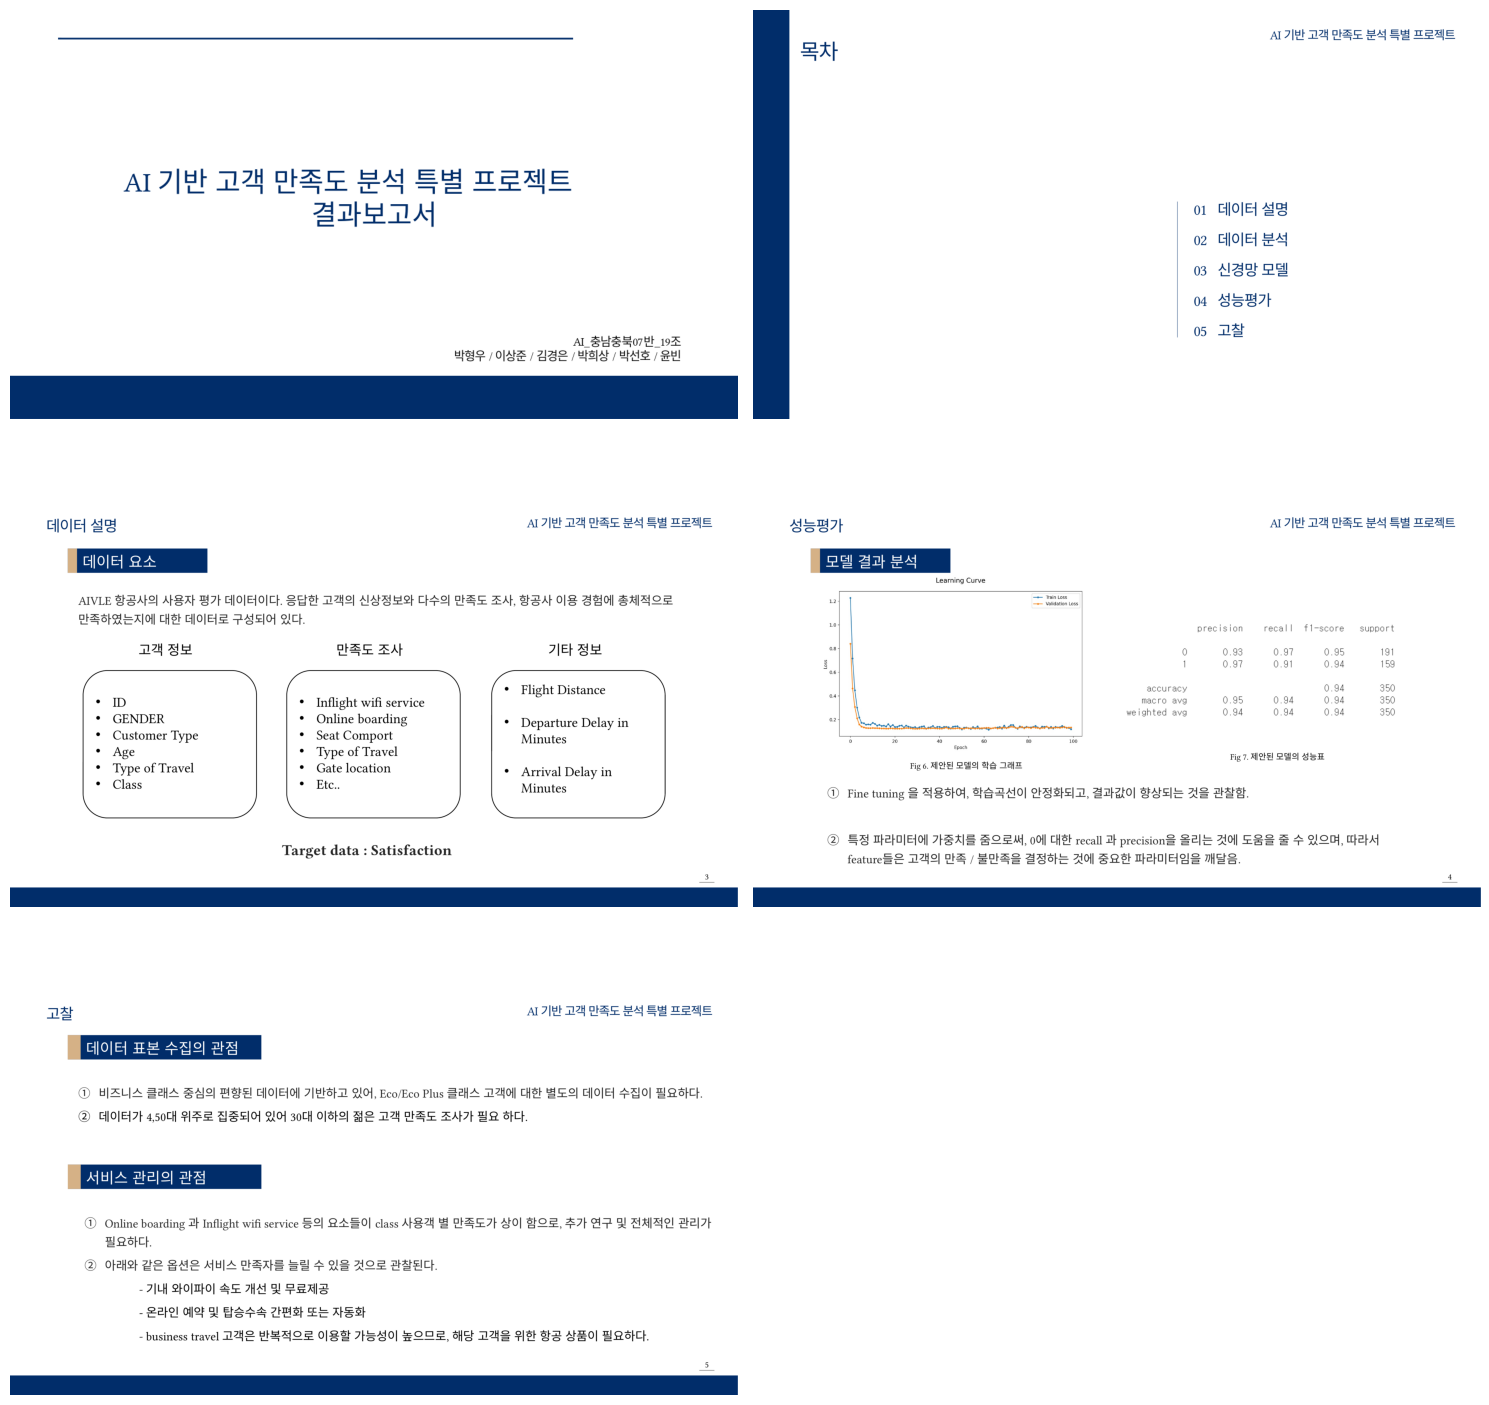

In [ ]:
# 슬라이드 이미지 조회 테스트
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

n = state["n_slides"]
cols = 2
rows = (n + cols - 1) // cols

plt.figure(figsize=(15, 5 * rows))

for idx, slide in enumerate(state["slides"]):
    img_path = slide.get("snap")
    title = slide.get("title", f"Slide {idx+1}")

    plt.subplot(rows, cols, idx + 1)
    if img_path and os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.imshow(img)
    else:
        plt.text(0.5, 0.5, f"이미지 없음\n{img_path}", ha='center', va='center')

    plt.axis('off')

plt.tight_layout()
plt.show()

### (4) 내용 생성

* 목적: 슬라이드 내용을 text로 정리
* 입력 : text, image, 표, 슬라이드 제목
* 출력 : 슬라이드 설명문
* 처리
    * 슬라이드 제목으로 SerpAPI 검색 및 요약
    * text, image, 표에 대한 설명문 생성
    * 전체 설명문 작성

#### **1) 외부 검색 노드**


In [ ]:
tavily_tool = TavilySearch(max_results=3)

def web_search_by_title(title: str) -> str:
    """
    TavilySearch 결과를 안전하게 문자열로 변환합니다.
    데이터가 dict가 아닌 str로 들어올 경우 발생하는 에러를 방지합니다.
    """
    if not title or not title.strip() or title.startswith("Slide"):
        return "(검색 결과 없음: 유효한 제목이 아닙니다.)"

    try:
        # 도구 호출
        search_result = tavily_tool.invoke({"query": title})

        # 1. 결과가 비어있는 경우
        if not search_result:
            return "(검색 결과 없음)"

        # 2. 결과가 이미 문자열(str)인 경우 (에러 메시지 등) 바로 반환
        if isinstance(search_result, str):
            return search_result

        # 3. 결과가 리스트(list)인 경우 안전하게 파싱
        if isinstance(search_result, list):
            lines = []
            for res in search_result:
                # 리스트 내부 요소가 딕셔너리일 때만 .get() 사용
                if isinstance(res, dict):
                    t = res.get("title", "No Title")
                    c = res.get("content", "내용 없음")
                    u = res.get("url", "URL 없음")
                    lines.append(f"- **{t}**\n  {c}\n  참조: {u}")
                else:
                    # 딕셔너리가 아니라면 문자열로 변환하여 추가
                    lines.append(str(res))

            return "\n\n".join(lines) if lines else "(검색 결과 형식이 올바르지 않습니다.)"

        return str(search_result)

    except Exception as e:
        return f"(Tavily 도구 실행 중 오류 발생: {str(e)})"

def node_tool_search(state: dict) -> dict:
    """
    현재 슬라이드 인덱스의 제목을 사용하여 외부 정보를 검색합니다.
    결과는 state['cur_search_context']에 저장됩니다.
    """
    idx = state.get("slide_index", 0)

    # 첫 번째 슬라이드(idx=0)에서는 외부 검색을 하지 않습니다.
    if idx == 0:
        state["cur_search_context"] = "(첫 번째 슬라이드에서는 외부 검색을 하지 않습니다.)"
        print(f"--- [슬라이드 {idx + 1}] 첫 번째 슬라이드이므로 외부 검색을 건너뜁니다. ---")
        return state

    # 슬라이드 데이터 존재 여부 확인
    if not state.get("slides") or idx >= len(state["slides"]):
        state["cur_search_context"] = "(검색할 슬라이드가 없습니다.)"
        return state

    slide = state["slides"][idx]
    # 제목이 없으면 Slide 번호로 검색 시도
    query = slide.get("title") or f"Slide {slide.get('index', idx + 1)}"

    print(f"--- [슬라이드 {idx + 1}] '{query}' 주제로 외부 지식 검색 중... ---")

    # 검색 실행 및 결과 적재
    state["cur_search_context"] = web_search_by_title(query)

    return state

In [ ]:
state = node_tool_search(state)
state

--- [슬라이드 1] 첫 번째 슬라이드이므로 외부 검색을 건너뜁니다. ---


{'pptx_path': 'test ppt 2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심'},
 'slides': [{'index': 1,
   'title': '',
   'texts': ['AI 기반 고객 만족도 분석 특별 프로젝트 결과보고서',
    'AI_충남충북07반_19조 박형우 / 이상준 / 김경은 / 박희상 / 박선호 / 윤빈'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/test ppt 2.png'},
  {'index': 2,
   'title': '',
   'texts': ['목차', 'AI 기반 고객 만족도 분석 특별 프로젝트'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '',
   'texts': ['데이터 설명',
    'AI 기반 고객 만족도 분석 특별 프로젝트',
    'AIVLE 항공사의 사용자 평가 데이터이다. 응답한 고객의 신상정보와 다수의 만족도 조사, 항공사 이용 경험에 총체적으로 만족하였는지에 대한 데이터로 구성되어 있다.',
    'Target data : Satisfaction'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-3.png'},
  {'index': 4,
   'title': '',
   'texts': ['성능평가',
    'Fine tuning 을 적용하여, 학습곡선이 안정화되고, 결과값이 향상되는 것을 관찰함. 특정 파라미터에 가중치를 줌으로써, 0에 대한 recall 과 p

#### **2) 내용 생성 함수**

In [ ]:
def node_generate_text(state: State) -> State:
    # 1. 현재 슬라이드 정보 준비
    idx = state["slide_index"]
    slide = state["slides"][idx]

    title = slide.get("title", "")
    texts = slide.get("texts", [])
    tables = slide.get("tables", [])
    images = list(slide.get("images", []) or [])
    snap = slide.get("snap")  # 스냅샷을 이미지 목록 맨 앞에 삽입
    if snap and snap not in images:
        images.insert(0, snap)

    table_snip = ""
    search_context = ""

    if tables:
        try:
            table_snip = "\n".join([" | ".join(map(str, r)) for r in tables[0][:6]])
        except Exception:
            table_snip = str(tables[0][:6])


    ## 사용자가 입력한 강의 스타일
    prompt = state["prompt"]

    # 2. 메시지 구성 -----------------------
    ## 시스템 메시지
    sys_msg = f"""
    너는 슬라이드 내용을 설명하는 AI 강사야.
    다음 규칙을 반드시 지켜야 해.
    1. 슬라이드의 텍스트, 표, 이미지를 기반으로 페이지 요약 문단을 생성한다.
    2. 표는 첫 번째 표의 앞 6행만 참고하며 핵심 내용만 반영한다.
    3. 이미지는 최대 3개까지 참고하며 이미지 내용을 반드시 포함한다.
    4. 과장하지 않는다.
    5. 4~6 문장으로 작성한다.
    6. 불릿포인트 사용을 금지한다.
    7.  사용자가 제공한 스타일(prompt)을 반영한다.
    tone: {prompt.get('tone', '')}
    style: {prompt.get('style', '')}
    """


    ## HumanMessage : 리스트로 구성해야 멀티모달 입력 가능
    user_text = []
    user_text.append(f"[제목]\n{title if title else '(없음)'}")
    user_text.append(f"[검색 보조 정보]\n{search_context if search_context else'(없음)'}")
    user_text.append(f"[텍스트]\n{texts if texts else '(없음)'}")
    user_text.append(f"[표 요약]\n{table_snip if table_snip else '(없음)'}")
    user_text = "\n\n".join(user_text)


    ### 멀티모달 HumanMessage 구성
    human_msg = [{"type": "text", "text": user_text}]

    MAX_IMGS = 3
    for image in images[:MAX_IMGS]:
      try:
        data_url = img_to_data_url(image) # base 64 변환
        human_msg.append({"type": "image_url", "image_url": {"url": data_url}})
      except Exception:
        pass

    # 3. llm.invoke()  ----------------
    response = llm.invoke([("system", sys_msg), ("human", human_msg)])

    state["page_contents"].append(response.content)  # 리스트에 누적
    state["cur_page_content"] = response.content      # 임시 보관

    return state


* 노드 테스트

In [ ]:
# 테스트
state = node_generate_text(state)
state

{'pptx_path': 'test ppt 2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심'},
 'slides': [{'index': 1,
   'title': '',
   'texts': ['AI 기반 고객 만족도 분석 특별 프로젝트 결과보고서',
    'AI_충남충북07반_19조 박형우 / 이상준 / 김경은 / 박희상 / 박선호 / 윤빈'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/test ppt 2.png'},
  {'index': 2,
   'title': '',
   'texts': ['목차', 'AI 기반 고객 만족도 분석 특별 프로젝트'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '',
   'texts': ['데이터 설명',
    'AI 기반 고객 만족도 분석 특별 프로젝트',
    'AIVLE 항공사의 사용자 평가 데이터이다. 응답한 고객의 신상정보와 다수의 만족도 조사, 항공사 이용 경험에 총체적으로 만족하였는지에 대한 데이터로 구성되어 있다.',
    'Target data : Satisfaction'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-3.png'},
  {'index': 4,
   'title': '',
   'texts': ['성능평가',
    'Fine tuning 을 적용하여, 학습곡선이 안정화되고, 결과값이 향상되는 것을 관찰함. 특정 파라미터에 가중치를 줌으로써, 0에 대한 recall 과 p

### (5) 강의 스크립트

* 목적 : 슬라이드 요약(page_content)을 기반으로 60~90초 분량의 발표 대본(스크립트)을 작성하고 저장
* 입력:
    * 슬라이드 설명문
    * tone, 말투 지시 프롬프트
    * 스크립트 저장 디렉토리
    * 이전 페이지의 강의 스크립트(맥락/흐름 파악용)
* 출력: 생성된 발표 스크립트

* 노드 함수 생성

In [ ]:
def node_generate_script(state: State) -> State:
    # 1. 슬라이드에서 사용할 정보 준비 ---------------
    prompt = state.get("prompt", {})
    tone = prompt.get("tone", "")
    work_dir = state.get("work_dir", "./")

    # Ensure state["scripts"] is initialized as an empty list if not present
    if "scripts" not in state or state["scripts"] is None:
        state["scripts"] = []

    # Use state["scripts"] for previous context, not state["cur_script"]
    prev_script_join = "\n".join(state["scripts"]) if state["scripts"] else "(이전 스크립트 없음)"
    cur = state["cur_page_content"]
    idx=state["slide_index"]
    summary = state.get("cur_summary", "") # 이전 슬라이드 요약 가져오기

    # 2. 메시지 구성 -----------------------
    # 조건에 이전 페이지 참고 언급.
    sys_msg = f"""
    [역할]
    너는 슬라이드 내용을 단순히 읽어주는 AI 강사가 아니라, 발표자가 청중에게 전달해야 할 핵심 메시지를 자연스러운 한국어 발표 대본으로 바꾸는 보조 에이전트야.
    너의 목표는 현재 슬라이드가 발표 흐름에서 어떤 역할을 하는지 판단하고, 발표자가 왜 이 내용을 보여주는지 청중이 이해할 수 있도록 말로 풀어내는 것이다.
    **이 과정에서 공통 원칙을 지키며 추가적으로 {idx}의 크기에 따라 본문 출력 형식 또는 슬라이드 출력 형식을 따른다.**

    [현재 정보]
    - 현재 슬라이드 인덱스: {idx}
    - 발표 말투: {tone}
    - [현재 페이지] : {cur}

    [슬라이드 출력 형식] **현재 슬라이드 인덱스 {idx}가 0또는 1인 슬라이드는 아래와 같은 지침을 따라 출력한다.**
        1. 전체 분량은 10초 발표 분량으로 작성한다.
        2. 현재 슬라이드 인덱스 {idx}가 0 슬라이드는 인사 및 발표 주제에 대한 스크립트를 작성한다.
        3. 현재 슬라이드 인덱스 {idx}가 1인 슬라이드는 ppt에 기입된 발표 순서에 대한 스크립트를 작성한다.
        4. 지침 외의 설명은 하지 않는다.

    [본문 출력 형식] **현재 슬라이드 인덱스 {cur}가 2 이상인 슬라이드는 아래와 같은 지침을 따라 출력한다.**
        1. 전체 분량은 60~90초 발표 분량으로 작성한다.
        2. 첫 문장은 현재 슬라이드의 핵심 메시지로 시작한다.
        3.  슬라이드 내 근거를 바탕으로 핵심 내용을 설명한 후.
        4. 현재 페이지 내용에서 확인 가능한 근거를 최소 2개 반영한다.
        5. 그림, 표, 수식, 그래프가 언급되어 있다면 청중이 무엇을 봐야 하는지 설명한다.

    [공통 원칙]
    1. 슬라이드 내용을 그대로 읽거나 단순 요약하지 않는다.
    2. 발표자가 왜 이 내용을 보여주는지 설명한다.
    3. 인사는 현재 슬라이드 인덱스 {idx}가 0인 슬라이드에서만 한다.
    4. 이전 스크립트는 발표 흐름을 위한 맥락 참고용으로만 사용한다.
    5. 이전 슬라이드와 중복되는 설명은 줄인다.
    6. **슬라이드에 없는 성과, 의의, 적용 가능성, 기대효과를 임의로 만들지 않는다.**
    7. "중요하다", "효과적이다", "의미가 있다", "기여한다", "우수하다" 같은 추상 표현은 구체적 근거 없이 사용하지 않는다.
    8. 메타 문장, 예를 들어 "다음은 발표 스크립트입니다", "이렇게 말하면 됩니다" 같은 표현은 쓰지 않는다.
    9. 사용자가 지정한 말투 {tone}를 반영하고, 발표 전체에서 용어를 일관되게 사용한다.
    10. 억지로 해당 슬라이드를 끝맺는 스크립트를 넣지 않는다.
    11. **제목, 분석, 해설, 주석, 불릿포인트, 메타 설명은 출력하지 않는다.**
    12. **슬라이드의 디자인에 대한 설명을 하지 않는다.** """


    user_msg = f"""
    [이전까지의 페이지]
    {summary if summary else '(없음)'}
    [현재 페이지]
    {cur}

    [말투] {tone}
        """
    # 3. llm.invoke()  ----------------
    # writer_llm 으로 새로운 llm 생성 후 이를 사용(temperature을 수정함)
    writer_llm = ChatOpenAI(model=LLM_MODEL, temperature=0.4)
    response = writer_llm.invoke([("system", sys_msg), ("human", user_msg)])
    script = response.content
    state["cur_script"] = script # Correctly set cur_script
    state["scripts"].append(script) # ADD: Append to the list of all scripts
    script_path = os.path.join(work_dir, "script.txt")
    with open(script_path, "w", encoding="utf-8") as f: f.write(script)
    return state

* 테스트

In [ ]:
# 테스트
state = node_generate_script(state)
state

{'pptx_path': 'test ppt 2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심'},
 'slides': [{'index': 1,
   'title': '',
   'texts': ['AI 기반 고객 만족도 분석 특별 프로젝트 결과보고서',
    'AI_충남충북07반_19조 박형우 / 이상준 / 김경은 / 박희상 / 박선호 / 윤빈'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/test ppt 2.png'},
  {'index': 2,
   'title': '',
   'texts': ['목차', 'AI 기반 고객 만족도 분석 특별 프로젝트'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '',
   'texts': ['데이터 설명',
    'AI 기반 고객 만족도 분석 특별 프로젝트',
    'AIVLE 항공사의 사용자 평가 데이터이다. 응답한 고객의 신상정보와 다수의 만족도 조사, 항공사 이용 경험에 총체적으로 만족하였는지에 대한 데이터로 구성되어 있다.',
    'Target data : Satisfaction'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-3.png'},
  {'index': 4,
   'title': '',
   'texts': ['성능평가',
    'Fine tuning 을 적용하여, 학습곡선이 안정화되고, 결과값이 향상되는 것을 관찰함. 특정 파라미터에 가중치를 줌으로써, 0에 대한 recall 과 p

- 리뷰 및 FAQ 생성

In [ ]:
def generate_faq(final_script, llm):
    """
    최종 스크립트를 바탕으로 예상 질문과 답변을 생성합니다.
    """
    prompt = f"""
    당신은 전문 강사입니다. 아래 강의 스크립트를 읽고,
    학습자들이 가장 어려워하거나 더 알고 싶어 할 법한 '예상 질문' 3개와
    그에 대한 '명쾌한 답변'을 작성해주세요.

    [강의 스크립트]
    {final_script}

    [형식]
    Q1: 질문 내용
    A1: 답변 내용
    ...
    """

    # 기존 리뷰 노드와 동일한 llm 객체를 사용하여 호출
    response = llm.invoke(prompt)
    return response.content


# 리뷰 및 FAQ 생성 노드
def node_review_script(state: State) -> State:
    print(f"--- [슬라이드 {state['slide_index'] + 1}] 스크립트 내용 검토 중... ---")

    page_content = state.get("cur_page_content", "")
    generated_script = state.get("cur_script", "")

    prompt = f"""
    당신은 전문 교육 콘텐츠 리뷰어입니다.
    아래 [PPT 페이지 내용]을 바탕으로 작성된 [강의 스크립트]를 검토하세요.

    [PPT 페이지 내용]:
    {page_content}

    [강의 스크립트]:
    {generated_script}

    검토 기준: 키워드 포함 여부, 구어체 자연스러움, 내용 오류 확인.
    마지막 줄에 반드시 '결과: 통과' 또는 '결과: 수정필요'라고 적어주세요.
    """

    response = llm.invoke(prompt)
    review_feedback = response.content
    state["review_feedback"] = review_feedback

    if "통과" in review_feedback:
        state["review_result"] = "PASS"
        print(f"검토 결과: {state['review_result']}")

        # === FAQ 생성 ===
        print(f"--- [슬라이드 {state['slide_index'] + 1}] FAQ 생성 중... ---")
        faq_result = generate_faq(generated_script, llm)

        # [중요] 누적 로직: 기존에 저장된 total_faq가 있으면 가져오고, 없으면 빈 문자열로 시작
        current_total_faq = state.get("total_faq", "")
        if current_total_faq is None: current_total_faq = ""

        # 슬라이드 번호와 함께 내용을 덧붙임
        new_entry = f"\n### 💡 슬라이드 {state['slide_index'] + 1} 예상 질문\n{faq_result}\n"
        state["total_faq"] = current_total_faq + new_entry # 덮어쓰지 않고 더함!

        state["cur_faq"] = faq_result
        print(f"--- FAQ 생성 및 누적 완료 ---")

    else:
        state["review_result"] = "RETRY"
        print(f"검토 결과: {state['review_result']}")

    return state

In [ ]:
# 테스트
state = node_review_script(state)
state

--- [슬라이드 1] 스크립트 내용 검토 중... ---
검토 결과: PASS
--- [슬라이드 1] FAQ 생성 중... ---
--- FAQ 생성 및 누적 완료 ---


{'pptx_path': 'test ppt 2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심'},
 'slides': [{'index': 1,
   'title': '',
   'texts': ['AI 기반 고객 만족도 분석 특별 프로젝트 결과보고서',
    'AI_충남충북07반_19조 박형우 / 이상준 / 김경은 / 박희상 / 박선호 / 윤빈'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/test ppt 2.png'},
  {'index': 2,
   'title': '',
   'texts': ['목차', 'AI 기반 고객 만족도 분석 특별 프로젝트'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '',
   'texts': ['데이터 설명',
    'AI 기반 고객 만족도 분석 특별 프로젝트',
    'AIVLE 항공사의 사용자 평가 데이터이다. 응답한 고객의 신상정보와 다수의 만족도 조사, 항공사 이용 경험에 총체적으로 만족하였는지에 대한 데이터로 구성되어 있다.',
    'Target data : Satisfaction'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-3.png'},
  {'index': 4,
   'title': '',
   'texts': ['성능평가',
    'Fine tuning 을 적용하여, 학습곡선이 안정화되고, 결과값이 향상되는 것을 관찰함. 특정 파라미터에 가중치를 줌으로써, 0에 대한 recall 과 p

- 이전 페이지 요약

In [ ]:
def node_summarize_script(state: State) -> State:

    # 이전페이지의 핵심을 요약해서 다음페이지에 전달
    # 1. 스크립트 생성 -> 스크립트 요약
    # 2. 스크립트 생성 시 요약 확인
    # 2-1. 만약 요약이 없다면(첫 페이지), "없음"으로 처리
    # 2-2. 만약 요약이 있다면, 요약을 불러오고 리턴
    # 3. node_generate_script의 sys_msg에 이전 페이지의 요약을 전달

    # 현재 슬라이드 스크립트 준비
    cur_script = state["cur_script"]

    # 스크립트를 요약하라고 지시
    sys_msg = f'''
    [역할]
    너는 PPT 발표 스크립트를 요약하는 에이전트야.
    아래 조건을 준수하여 제공되는 스크립트의 내용을 요약해.
    [조건]
    - 한국어로 작성할 것
    - 과장하지 말고 사실에 기반하여 작성할 것
    - 줄글형으로 작성하지 말고, 내용을 구조화해서 작성할 것
    - 제공된 스크립트의 절반 분량으로 요약할 것
    '''

    # 시스템 메시지와 현재 슬라이드의 스크립트를 제공한 메시지
    messages = [
        SystemMessage(content=sys_msg),
        HumanMessage(content=cur_script)
    ]

    # GPT에게 전달해서 요약 결과 받기
    response = llm.invoke(messages)

    # 요약 state에 추가
    state["cur_summary"] = response.content

    # summary list 초기화
    if "summary" not in state:
        state["summary"] = []

    state["summary"].append(response.content)

    return state

In [ ]:
# 테스트
state = node_summarize_script(state)
state

{'pptx_path': 'test ppt 2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심'},
 'slides': [{'index': 1,
   'title': '',
   'texts': ['AI 기반 고객 만족도 분석 특별 프로젝트 결과보고서',
    'AI_충남충북07반_19조 박형우 / 이상준 / 김경은 / 박희상 / 박선호 / 윤빈'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/test ppt 2.png'},
  {'index': 2,
   'title': '',
   'texts': ['목차', 'AI 기반 고객 만족도 분석 특별 프로젝트'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '',
   'texts': ['데이터 설명',
    'AI 기반 고객 만족도 분석 특별 프로젝트',
    'AIVLE 항공사의 사용자 평가 데이터이다. 응답한 고객의 신상정보와 다수의 만족도 조사, 항공사 이용 경험에 총체적으로 만족하였는지에 대한 데이터로 구성되어 있다.',
    'Target data : Satisfaction'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-3.png'},
  {'index': 4,
   'title': '',
   'texts': ['성능평가',
    'Fine tuning 을 적용하여, 학습곡선이 안정화되고, 결과값이 향상되는 것을 관찰함. 특정 파라미터에 가중치를 줌으로써, 0에 대한 recall 과 p

## **3. 미션④ : 모듈 고도화2**

* 음성 변환 : 강의 목소리, 톤 조절 프롬프트 기반 음성 변환
* 영상 제작 : 각 슬라이드 강의를 전체 슬라이드 강의 영상으로 합치기
* 전체 Agent 그래프 구축
* 웹 화면 연결(gradio)



### (1) 음성 변환

* 목적 : 발표 스크립트(script)를 TTS 모델을 이용해 음성(mp3) 파일로 변환하고 state에 저장
* 입력
    * 발표 스크립트
    * 목소리 프리셋. 기본값 "alloy"
* 출력: 생성된 mp3 파일 및 경로

* 노드 함수 생성

In [ ]:
def node_tts(state: State) -> State:
    client = OpenAI()

    prompt = state.get("prompt", {})
    tone = prompt.get("tone", "")

    resp = client.audio.speech.create(
        model = TTS_MODEL,                             # gpt-4o-mini-tts
        voice = state['prompt'].get('voice', 'alloy'), # 지정된 것이 없다면, default: alloy
        input = state['cur_script'],                   # 현재 스크립트 불러오기
        instructions=f"""{tone}
                        전문 강사처럼 설명하고,
                        이해를 돕기 위해 자연스럽게 말한다.
                        속도는 약간 느리게 유지한다."""
    )

    # 음성 파일 저장
    # 현재 슬라이드 인덱스 + 1
    mp3_path = os.path.join(state["work_dir"], f"narration_{state['slide_index']+1}.mp3")
    with open(mp3_path, "wb") as f:
        f.write(resp.content)

    # MP3 파일 길이 출력
    duration = ffprobe_duration(mp3_path)
    print(f"{mp3_path} 길이: {duration:.2f}초")

    # state에 음성 파일 경로 저장
    state["cur_audio"] = mp3_path

    # 반환
    return state

* 노드 테스트

In [ ]:
# 테스트
state = node_tts(state)
state

./step2_output/narration_1.mp3 길이: 52.32초


{'pptx_path': 'test ppt 2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심'},
 'slides': [{'index': 1,
   'title': '',
   'texts': ['AI 기반 고객 만족도 분석 특별 프로젝트 결과보고서',
    'AI_충남충북07반_19조 박형우 / 이상준 / 김경은 / 박희상 / 박선호 / 윤빈'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/test ppt 2.png'},
  {'index': 2,
   'title': '',
   'texts': ['목차', 'AI 기반 고객 만족도 분석 특별 프로젝트'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '',
   'texts': ['데이터 설명',
    'AI 기반 고객 만족도 분석 특별 프로젝트',
    'AIVLE 항공사의 사용자 평가 데이터이다. 응답한 고객의 신상정보와 다수의 만족도 조사, 항공사 이용 경험에 총체적으로 만족하였는지에 대한 데이터로 구성되어 있다.',
    'Target data : Satisfaction'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-3.png'},
  {'index': 4,
   'title': '',
   'texts': ['성능평가',
    'Fine tuning 을 적용하여, 학습곡선이 안정화되고, 결과값이 향상되는 것을 관찰함. 특정 파라미터에 가중치를 줌으로써, 0에 대한 recall 과 p

In [ ]:
# 오디오 play
from IPython.display import Audio, display
audio_path = state['cur_audio']
display(Audio(filename=audio_path))
print("Audio file:", audio_path)

Audio file: ./step2_output/narration_1.mp3


### (2) 영상 제작
* 목적 : 슬라이드 이미지와 음성을 합쳐 mp4 영상 생성
* 입력: 오디오 파일, 이미지(스냅샷)
* 출력: 생성된 mp4 파일 및 경로

* 노드 함수 생성

In [ ]:
def node_make_video(state: State) -> State:
    # 1. 현재 슬라이드 인덱스 가져오기
    slide_index = state['slide_index']
    # 2. 해당 슬라이드의 snap(이미지 경로) 가져오기
    slide_image = state['slides'][slide_index]['snap']

    # 3. 현재 슬라이드에 대응하는 오디오 경로 가져오기
    audio_path = state.get('cur_audio')

    # 4. 영상 저장 폴더(media 디렉토리) 경로 설정
    media_dir = os.path.join(state['work_dir'], 'media')
    # 5. 슬라이드별 영상 파일 이름 생성
    video_filename = f'slide{slide_index}_lecture.mp4'
    # 6. 최종 영상 파일 전체 경로 생성
    out_mp4 = os.path.join(media_dir, video_filename)
    # 7. 이미지 + 음성 → 영상(mp4) 생성
    render_mp4(slide_image, audio_path, out_mp4)
    # 8. 현재 슬라이드 영상 경로 state에 저장
    state['cur_video'] = out_mp4
    # 7. 전체 영상 리스트에 누적
    videos = state.get('videos', [])
    # 10. 생성된 영상 경로 리스트에 추가
    videos.append(out_mp4)
    # 11. 업데이트된 영상 리스트를 state에 다시 저장
    state['videos'] = videos
    return state

* 노드 테스트

In [ ]:
# 테스트
state = node_make_video(state)
state

{'pptx_path': 'test ppt 2.pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심'},
 'slides': [{'index': 1,
   'title': '',
   'texts': ['AI 기반 고객 만족도 분석 특별 프로젝트 결과보고서',
    'AI_충남충북07반_19조 박형우 / 이상준 / 김경은 / 박희상 / 박선호 / 윤빈'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/test ppt 2.png'},
  {'index': 2,
   'title': '',
   'texts': ['목차', 'AI 기반 고객 만족도 분석 특별 프로젝트'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '',
   'texts': ['데이터 설명',
    'AI 기반 고객 만족도 분석 특별 프로젝트',
    'AIVLE 항공사의 사용자 평가 데이터이다. 응답한 고객의 신상정보와 다수의 만족도 조사, 항공사 이용 경험에 총체적으로 만족하였는지에 대한 데이터로 구성되어 있다.',
    'Target data : Satisfaction'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-3.png'},
  {'index': 4,
   'title': '',
   'texts': ['성능평가',
    'Fine tuning 을 적용하여, 학습곡선이 안정화되고, 결과값이 향상되는 것을 관찰함. 특정 파라미터에 가중치를 줌으로써, 0에 대한 recall 과 p

In [ ]:
video_path = state["cur_video"]

with open(video_path, "rb") as f:
    data = f.read()

display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

### (3) 반복&종료 분기, 영상 합치기 노드
* 반복&종료 분기 : 마지막 슬라이드까지 반복 실행
* 각 슬라이드 영상을 하나의 영상으로 합치기

* State의 키(리스트)에 누적

In [ ]:
def node_acc_step(state: State) -> State:
  # This node needs to return a State *dictionary* to update the state,
  # and also indicate the next step for conditional routing.
  if state['slide_index'] < state['n_slides'] - 1:
      state['slide_index'] += 1 # Update slide_index in the current state
      state['route_decision'] = "continue" # Add a new key for routing
  else:
      state['route_decision'] = "done" # Add a new key for routing
  return state # Return the modified state

* 분기 함수

* 영상 합치기
    * concat_videos_ffmpeg 사용

In [ ]:
def node_concat(state: State) -> State:
  video_list = state.get('videos', [])
  work_dir = state.get('work_dir', './')

  final_video_path = os.path.join(work_dir, "final_lecture.mp4")

  if video_list:
      concat_videos_ffmpeg(video_list, final_video_path)

  state['final_video'] = final_video_path

  return state

### 요약본 작성

In [ ]:
#내용 요약 추가
def node_make_summary(state: State) -> State:
    work_dir = state.get("work_dir", "./")
    purpose = state.get("prompt", {}).get("summary_purpose", "발표 복습용 요약")

    slide_titles = [
        s.get("title") or f"Slide {i+1}"
        for i, s in enumerate(state.get("slides", []))
    ]

    page_contents = "\n\n".join(state.get("page_contents", []))
    scripts = "\n\n".join(state.get("scripts", []))

    prompt = f"""
너는 발표 자료를 청중이 이해하기 쉽게 정리하는 AI 강사다.

[요약 목적]
{purpose}

[슬라이드 제목]
{slide_titles}

[페이지 핵심 내용]
{page_contents}

[발표 스크립트]
{scripts}

[작성 조건]
1. 기술 개념을 모르는 사람도 이해할 수 있도록 쉽게 설명한다.
2. 발표 흐름이 자연스럽게 이어지도록 정리한다.
3. 핵심 개념 → 문제 상황 → 해결 방법 → 구조 순서로 정리한다.
4. 불필요한 반복은 제거하고 핵심만 남긴다.
5. 한 문장은 너무 길지 않게 작성한다.

[출력 형식]

[한 줄 핵심 요약]
- 이 발표의 핵심 메시지를 한 문장으로 정리

[개념 설명]
- 모델 모니터링이 무엇인지 쉽게 설명

[왜 필요한가 (문제)]
- 어떤 문제가 발생하는지 (드리프트, 데이터 문제 등)

[어떻게 해결하는가]
- 모니터링을 통해 무엇을 할 수 있는지

[구조 및 방식]
- Batch vs Streaming 등 핵심 구조 설명

[청중이 기억할 포인트]
- 청중이 반드시 기억해야 할 3~5개 핵심 포인트
"""

    response = llm.invoke(prompt)
    summary = response.content

    summary_path = os.path.join(work_dir, "lecture_summary.txt")
    with open(summary_path, "w", encoding="utf-8") as f:
        f.write(summary)

    state["summary_text"] = summary
    state["summary_path"] = summary_path

    return state

In [ ]:
!pip install reportlab #추가 pdf
!apt-get -y install fonts-nanum #추가

#추가
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.lib.pagesizes import A4
import os

# 한글 폰트 등록
pdfmetrics.registerFont(
    TTFont("NanumGothic", "/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.2 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 108 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,154 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 131340 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
def node_make_summary_pdf(state: State) -> State:
    work_dir = state.get("work_dir", "./")
    summary_text = state.get("summary_text", "요약 없음")

    pdf_path = os.path.join(work_dir, "lecture_summary.pdf")

    doc = SimpleDocTemplate(
        pdf_path,
        pagesize=A4,
        rightMargin=40,
        leftMargin=40,
        topMargin=40,
        bottomMargin=40
    )

    style = ParagraphStyle(
        name="KoreanStyle",
        fontName="NanumGothic",
        fontSize=11,
        leading=17
    )

    story = []

    for line in summary_text.split("\n"):
        if line.strip():
            story.append(Paragraph(line.replace(" ", "&nbsp;"), style))
        story.append(Spacer(1, 8))

    doc.build(story)

    state["summary_pdf"] = pdf_path
    return state

### (4) Agent 만들기 : 그래프로 엮기
* 다음 그래프를 참조로 하나의 에이전트로 엮어 봅시다.

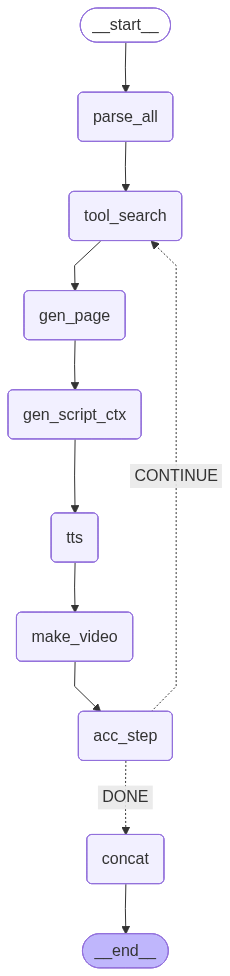

In [ ]:
from langgraph.graph import StateGraph, START, END

# 그래프 생성
builder = StateGraph(State)

# 그래프 노드 추가
builder.add_node("parse_all", node_parse_all) # PPT 정보 분해
builder.add_node("tool_search", node_tool_search)
builder.add_node("gen_text", node_generate_text)
builder.add_node("gen_script", node_generate_script) # 강의 스크립트 생성
builder.add_node("review_script", node_review_script) # [추가] 스크립트 내용 검토
builder.add_node("summ_script", node_summarize_script) # [추가] 스크립트 요약
builder.add_node("tts", node_tts) # 음성 변환
builder.add_node("make_video", node_make_video) # 영상 제작
builder.add_node("acc_step", node_acc_step) # 반복 결정 분기
builder.add_node("concat", node_concat) # 영상 합치기
builder.add_node("make_summary", node_make_summary) #추가
builder.add_node("make_summary_pdf", node_make_summary_pdf) #추가

# 그래프 엣지 연결
builder.set_entry_point("parse_all")
builder.add_edge("parse_all", "tool_search")
builder.add_edge("tool_search", "gen_text")
builder.add_edge("gen_text", "gen_script")
builder.add_edge("gen_script", "review_script")

# [추가됨] review_script 결과에 따른 조건부 분기
builder.add_conditional_edges(
    "review_script",
    lambda state: state.get("review_result", "PASS"), # PASS 또는 RETRY 반환
    {
        "PASS": "summ_script",          # 통과하면 summ_script으로 이동
        "RETRY": "gen_script"   # 수정 필요하면 다시 대본(gen_script) 생성으로 이동
    }
)

# builder.add_edge("review_script", "summ_script")
builder.add_edge("summ_script", "tts")
builder.add_edge("tts", "make_video")
builder.add_edge("make_video", "acc_step")

# Conditional edges for acc_step
builder.add_conditional_edges(
    "acc_step",
    lambda state: state["route_decision"], # Use the new key from node_acc_step for routing
    {
        "continue": "tool_search", # If 'continue', loop back to tool_search for the next slide
        "done": "concat"        # If 'done', proceed to concatenate videos
    }
)
builder.add_edge("concat", "make_summary") #추가
builder.add_edge("make_summary", "make_summary_pdf") #추가
builder.add_edge("make_summary_pdf", END) #추가

# 앱 컴파일 하기
app = builder.compile()

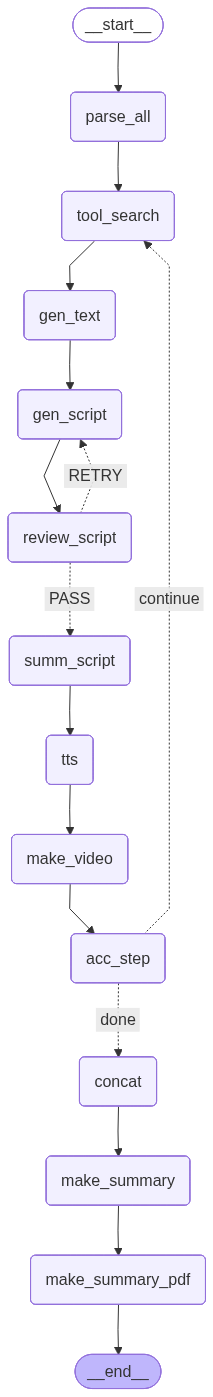

In [ ]:
app

## **4. 시스템 실행**

미션3,4에서 수행한 결과를 통합 테스트 해 봅시다.

### (1) 준비 작업
* 파일 업로드
* 사용자 프롬프트 준비

In [ ]:
# 파일 업로드
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving test ppt 2.pptx to test ppt 2 (1).pptx


In [ ]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "alloy",
    "tone": "전문적인 지식을 가진 인기 강사 톤",
    "style": "예시와 핵심 요점 중심",
    "summary_purpose":"논문 발표 복습용 요약" #추가
}
# 출력 dir 만들기
WORK_DIR = "./step2_output"
MEDIA_DIR = "./step2_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) Agent 실행
* State 초기화
* app 실행
* 동영상 play

In [ ]:
state: State = {"pptx_path": pptx_path, "work_dir": WORK_DIR, "prompt": USER_PROMPT}
state

{'pptx_path': 'test ppt 2 (1).pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심',
  'summary_purpose': '논문 발표 복습용 요약'}}

In [ ]:
# 전체 그래프 실행
final_state = app.invoke(state)

--- [슬라이드 1] 첫 번째 슬라이드이므로 외부 검색을 건너뜁니다. ---
--- [슬라이드 1] 스크립트 내용 검토 중... ---
검토 결과: RETRY
--- [슬라이드 1] 스크립트 내용 검토 중... ---
검토 결과: PASS
--- [슬라이드 1] FAQ 생성 중... ---
--- FAQ 생성 및 누적 완료 ---
./step2_output/narration_1.mp3 길이: 43.92초
--- [슬라이드 2] 'Slide 2' 주제로 외부 지식 검색 중... ---
--- [슬라이드 2] 스크립트 내용 검토 중... ---
검토 결과: PASS
--- [슬라이드 2] FAQ 생성 중... ---
--- FAQ 생성 및 누적 완료 ---
./step2_output/narration_2.mp3 길이: 79.56초
--- [슬라이드 3] 'Slide 3' 주제로 외부 지식 검색 중... ---
--- [슬라이드 3] 스크립트 내용 검토 중... ---
검토 결과: PASS
--- [슬라이드 3] FAQ 생성 중... ---
--- FAQ 생성 및 누적 완료 ---
./step2_output/narration_3.mp3 길이: 88.25초
--- [슬라이드 4] 'Slide 4' 주제로 외부 지식 검색 중... ---
--- [슬라이드 4] 스크립트 내용 검토 중... ---
검토 결과: PASS
--- [슬라이드 4] FAQ 생성 중... ---
--- FAQ 생성 및 누적 완료 ---
./step2_output/narration_4.mp3 길이: 56.57초
--- [슬라이드 5] 'Slide 5' 주제로 외부 지식 검색 중... ---
--- [슬라이드 5] 스크립트 내용 검토 중... ---
검토 결과: RETRY
--- [슬라이드 5] 스크립트 내용 검토 중... ---
검토 결과: PASS
--- [슬라이드 5] FAQ 생성 중... ---
--- FAQ 생성 및 누적 완료 ---
./step2_output/narration_5.mp3 

In [ ]:
final_state = node_make_summary_pdf(final_state)  #추가
print(final_state.get("summary_pdf"))  #추가
# 추가 pdf 추출
from google.colab import files
files.download(final_state["summary_pdf"])

./step2_output/lecture_summary.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
final_state

{'pptx_path': 'test ppt 2 (1).pptx',
 'work_dir': './step2_output',
 'prompt': {'voice': 'alloy',
  'tone': '전문적인 지식을 가진 인기 강사 톤',
  'style': '예시와 핵심 요점 중심',
  'summary_purpose': '논문 발표 복습용 요약'},
 'slides': [{'index': 1,
   'title': '',
   'texts': ['AI 기반 고객 만족도 분석 특별 프로젝트 결과보고서',
    'AI_충남충북07반_19조 박형우 / 이상준 / 김경은 / 박희상 / 박선호 / 윤빈'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-1.png'},
  {'index': 2,
   'title': '',
   'texts': ['목차', 'AI 기반 고객 만족도 분석 특별 프로젝트'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-2.png'},
  {'index': 3,
   'title': '',
   'texts': ['데이터 설명',
    'AI 기반 고객 만족도 분석 특별 프로젝트',
    'AIVLE 항공사의 사용자 평가 데이터이다. 응답한 고객의 신상정보와 다수의 만족도 조사, 항공사 이용 경험에 총체적으로 만족하였는지에 대한 데이터로 구성되어 있다.',
    'Target data : Satisfaction'],
   'tables': [],
   'images': [],
   'snap': '/content/step2_output/slide_img-3.png'},
  {'index': 4,
   'title': '',
   'texts': ['성능평가',
    'Fine tuning 을 적용하여, 학습곡선이 안정화되고, 결과값이 향상되는 것을

In [ ]:
# 영상 재생
video_path = final_state.get("final_video")
print("최종 영상:", video_path)

with open(video_path, "rb") as f:
    data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

## **5. Web APP 개발(Gradio)**
* 화면 개발
    * 입력 : ppt파일, 프롬프트(강의 작성톤), voice 선택(alloy, ...)
    * 출력 : 동영상 play, 동영상 다운로드 버튼
* 기본 화면을 제공합니다. 필요한 기능을 직접 추가하세요.
    * 그래프 컴파일 이름 : `app`
    * state에서 출력 비디오 이름 : `final_video`

In [ ]:
import os, time, shutil, re
import gradio as gr

VOICES = ["alloy", "aria", "verse", "shimmer", "coral", "sage", "nova", "amber"]

# FAQ 부분
def parse_faq(faq_text: str):
    """Q1:/A1: 포맷 → [(질문, 답변), ...] 파싱"""
    if not faq_text:
        return []
    pairs = []
    questions = re.findall(r'Q\d+:\s*(.+?)(?=A\d+:)', faq_text, re.DOTALL)
    answers   = re.findall(r'A\d+:\s*(.+?)(?=Q\d+:|$)', faq_text, re.DOTALL)
    for q, a in zip(questions, answers):
        pairs.append((q.strip(), a.strip()))
    return pairs

def run_pipeline_ui(pptx_file, tone, voice):

    # 경로 설정
    work_dir = os.path.join("./webio", f"run-{int(time.time())}")
    os.makedirs(work_dir, exist_ok=True)
    pptx_path = os.path.join(work_dir, "input.pptx")
    shutil.copy(pptx_file.name, pptx_path)

    # Default 사용자 프롬프트
    state = {
        "pptx_path": pptx_path,
        "work_dir": work_dir,
        "prompt": {
            "voice": voice or "alloy",
            "tone":  tone or "전문적인 지식을 가진 인기 강사 톤",
            "style": "예시와 핵심 요점 중심",
        },
    }

    final_state = app.invoke(state)
    video_path = final_state.get("final_video")
    summary_text = final_state.get("summary_text", "요약 없음")
    summary_pdf = final_state.get("summary_pdf")
    total_faq = final_state.get("total_faq", "")
    faq_pairs = parse_faq(total_faq)  # ← aq_pairs 오타 수정

    # ↓ faq_html 생성 추가
    if faq_pairs:
        faq_html = "<div style='display:flex; flex-direction:column; gap:10px;'>"
        for i, (q, a) in enumerate(faq_pairs, 1):
            faq_html += f"""
            <details style="background:#f9fafb; border:1px solid #e5e7eb; border-radius:12px; padding:14px 18px;">
                <summary style="cursor:pointer; font-weight:600; color:#111827; font-size:15px; list-style:none; display:flex; align-items:center; gap:8px;">
                    <span style="background:#00C7AE; color:white; border-radius:6px; padding:2px 8px; font-size:12px; flex-shrink:0;">Q{i}</span>
                    {q}
                </summary>
                <div style="margin-top:12px; padding-top:12px; border-top:1px solid #e5e7eb; color:#374151; font-size:14px; line-height:1.7;">
                    {a}
                </div>
            </details>"""
        faq_html += "</div>"
    else:
        faq_html = "<p style='color:#9ca3af; font-size:14px;'>생성된 FAQ가 없습니다.</p>"

    return video_path, video_path, faq_html, summary_text, summary_pdf, gr.update(visible=True)


# -------------------- UI --------------------

custom_css = """
body {
    background: #f9fafb;
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto;
}

.container {
    max-width: 720px;
    margin: auto;
    padding: 40px 20px;
}

.card {
    background: white;
    border-radius: 20px;
    padding: 30px;
    box-shadow: 0 4px 20px rgba(0,0,0,0.05);
    margin-bottom: 20px;
}

/* 타이틀 */
.title {
    font-size: 28px;
    font-weight: 700;
    margin-bottom: 10px;
    color: #00C7AE;
}

.subtitle {
    color: #6b7280;
    margin-bottom: 30px;
}

/* 업로드 영역 */
.upload-box {
    border: 2px dashed #00C7AE;
    border-radius: 16px;
    padding: 20px;
    transition: 0.2s;
}

.upload-box:hover {
    background: #f0fffc;
}

/* 버튼 */
.gr-button {
    background: #00C7AE !important;
    color: white !important;
    border-radius: 12px !important;
    height: 50px !important;
    font-size: 16px !important;
    transition: 0.2s;
}

.gr-button:hover {
    background: #00AFA0 !important;
}

/* 라디오 선택 강조 */
.gr-radio label {
    border-radius: 10px;
    padding: 8px;
}

.gr-radio input:checked + span {
    color: #00C7AE !important;
    font-weight: 600;
}

/* 결과 카드 */
.result-card {
    background: #ffffff;
    border-radius: 20px;
    padding: 20px;
    margin-top: 20px;
    border-top: 3px solid #00C7AE;
}

/*FAQ 카드*/
.faq-card    {
  background:#ffffff;
  border-radius:20px;
  padding:30px;
  margin-top:20px;
  border-top:3px solid #00C7AE;
}
"""

with gr.Blocks(css=custom_css) as demo:

    gr.HTML("""
    <div class="container">
        <div class="card">
            <div class="title">AI 강의 영상 생성기</div>
            <div class="subtitle">
                PPT를 업로드하면 자동으로 강의 영상을 생성합니다
            </div>
        </div>
    </div>
    """)

    with gr.Column(elem_classes="container"):

        # 입력 카드
        with gr.Column(elem_classes="card"):

            inp_ppt = gr.File(
                label="PPT 업로드",
                file_types=[".pptx"],
                elem_classes="upload-box"
            )

            inp_tone = gr.Textbox(
                value="친절하고 명료한 강의 톤",
                label="강의 스타일"
            )

            inp_voice = gr.Radio(
                VOICES,
                value="alloy",
                label="AI 음성 선택"
            )

            run_btn = gr.Button("영상 생성하기")

        # 결과 카드
        with gr.Column(elem_classes="result-card"):

            out_video = gr.Video(label="생성된 영상", interactive=False)
            out_download = gr.DownloadButton("영상 다운로드")

            out_summary = gr.Textbox(
			       label="요약 결과",
			       lines=15,
			       interactive=False
						    )

            out_summary_pdf = gr.File(
			        label="요약 PDF 다운로드"
						   )

        # FAQ 카드 (영상 생성 완료 후 표시)
        with gr.Column(elem_classes="faq-card", visible=False) as faq_section:
            gr.HTML("<div style='font-size:18px; font-weight:700; color:#111827; margin-bottom:16px;'> 강의 FAQ</div>")
            out_faq = gr.HTML()

    run_btn.click(
        run_pipeline_ui,
        [inp_ppt, inp_tone, inp_voice],
        [out_video, out_download, out_summary, out_summary_pdf, out_faq, faq_section],
    )

demo.launch()

/tmp/ipykernel_2335/3181162385.py:156: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ba6d458ce0ba84e73e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
